# Table of contents

### [1. Introduction](#introduction)
1.1. Project overview

1.2. Problem statement


### [2. Start Comet experiment](#scomet)
### [3. Import Packages and Modules](#packages)
### [4. Load data](#load)
### [5. Data Description](#dod)
### [6. Data pre-processing](#cleaning)
6.1. Null values

6.2. Duplicates

6.3. Column names


### [7. Connect notebook to SQL](#sql)
### [8. Exploratory Data Analysis](#eda)
8.1. Univariate Analysis

8.2. Bivariate Analysis

8.3. Multivariate Analysis

8.4. Correlation Analysis

8.5. Outlier Detection

8.6. Summary of EDA

### [9. Feature engineering](#pp)
9.1. Adding Features

9.2. Select feature and label variables

9.3. Encoding and Scaling

9.4. Feature Importance

### [10. Modeling](#mm)
### [11. Model Evaluation](#me)
### [12. Business Insights](#bi)
### [13. Conclusion](#con)
### [14. End Comet Experiment](#ecomet)

<a id="introduction"></a>
# 1. Introduction

## 1.1. Project overview

Customer churn is a significant challenge for financial institutions because losing existing customers can reduce revenue and increase the cost of acquiring new customers. Understanding the characteristics and behaviors associated with customer churn can help banks identify customers who may be at risk of leaving and take proactive retention measures.

This project analyzes customer demographic, financial, and account-related data to identify factors associated with customer churn. Exploratory data analysis is used to investigate patterns and relationships between customer characteristics and churn. Feature engineering and feature selection are then performed to improve the predictive value of the dataset. Several machine learning classification algorithms are trained and evaluated to determine their ability to identify customers who are likely to churn.


## 1.2  Problem statement

Develop a machine learning solution that can help a bank identify customers at higher risk of churn and support data-driven customer retention strategies.

<a id="scomet"></a>
# 2. Start Comet Experiment

Comet is a cloud-based platform that allows teams to preserve and compare the different models that have been built during a project. It is an effective tool for version control. I have saved all of my models as Comet experiments.

In [1]:
# import Experiment class
from comet_ml import Experiment

In [2]:
import os
os.environ["COMET_DISABLE_AUTO_LOGGING"] = "1"

In [3]:
# Start experiment
experiment = Experiment(api_key="TByjaRW33SUYdmIYC3R4V5tx6",
                        project_name="churn_prediction",
                        workspace="msibivee-gmail-com")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/msibivee-gmail-com/churn-prediction/05e86ffb580a49cc9d234638c12e9661



In [4]:
# Set experiment name, new name for each run
experiment.set_name('5th one')

<a id="packages"></a>
# 3. Import Packages and Modules

In [550]:
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Display settings 
sns.set_theme(style='whitegrid',palette='muted',font_scale=1.05)
pd.set_option('display.max_columns', 200)

# SQL
import sqlalchemy
from sqlalchemy import create_engine

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Data processing
from sklearn import preprocessing
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_predict, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline


# Model imports
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, roc_curve
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, classification_report, confusion_matrix
from collections import defaultdict

# Silence warnings for clean flow of notebook
import warnings
warnings.filterwarnings("ignore")

<a id="load"></a>
# 4. Load data

In [164]:
df = pd.read_csv('customer_data.csv')

In [165]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<a id="dod"></a>
# 5. Data Description

This dataset consists of 10000 customer information regarding their bank balance, estimated salary, and credit score. The data aslso shows demographic information and whether or not they possess a credit card.

In [90]:
df.shape

(10000, 12)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [92]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0


In [93]:
# Number of unique values
print('\nUnique values:')
print(df.nunique())


Unique values:
customer_id         10000
credit_score          460
country                 3
gender                  2
age                    70
tenure                 11
balance              6382
products_number         4
credit_card             2
active_member           2
estimated_salary     9999
churn                   2
dtype: int64


<a id="cleaning"></a>
# 6. Data pre-processing

## 6.1. Null values

In [94]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

There are no null values in the dataframe.

## 6.2. Duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

There are no duplicate columns.

## 6.3. Column names

In [15]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

Column names are consistent, easier to read, and easier to reference.

<a id="sql"></a>
# 7. Connect notebook to SQL

In [11]:
engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/customer_churn"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
table_name = "churn"

df.to_sql(name=table_name, con=engine, if_exists="replace", index= False)
print(f"Data successfully loaded into table '{table_name}' in database .")  

Data successfully loaded into table 'churn' in database .


<a id="eda"></a>
# 8. Exploratory Data Analysis And Insights

For easier interpretation of visuals credit_card, active_member, and churn will be given labels.

In [16]:
df_plot = df.copy()

df_plot['credit_card'] = df_plot['credit_card'].map({1: 'Yes', 0 : 'No'})
df_plot['active_member'] = df_plot['active_member'].map({1: 'Active', 0: 'Inactive'})
df_plot['churn'] = df_plot['churn'].map({1: 'Churned', 0 :'Not Churned'})

## 8.1 Univariate Analysis

|       |   credit_score |
|:------|---------------:|
| count |     10000      |
| mean  |       650.529  |
| std   |        96.6533 |
| min   |       350      |
| 25%   |       584      |
| 50%   |       652      |
| 75%   |       718      |
| max   |       850      |


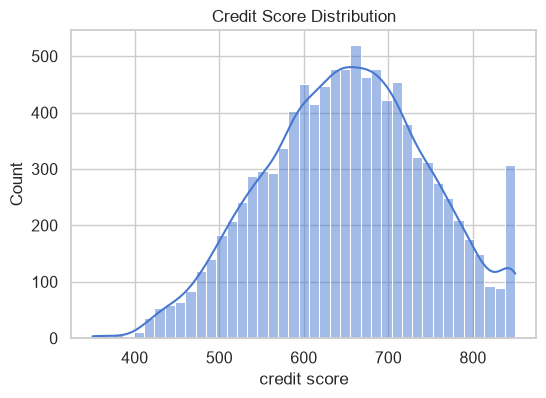

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
graph = sns.histplot(x='credit_score', data=df_plot, ax=ax,kde=True)  #use KDE=True to make the distribution easier to interpret
plt.title('Credit Score Distribution')
plt.xlabel('credit score', fontsize=12)
plt.ylabel('Count', fontsize=12)

print(df['credit_score'].describe().to_markdown())

The overall plot reflects a financially healthy, mainstream consumer base centered around a 650 average score, but it highlights a unique, highly creditworthy segment capped at the maximum limit.

|       |   estimated_salary |
|:------|-------------------:|
| count |           10000    |
| mean  |          100090    |
| std   |           57510.5  |
| min   |              11.58 |
| 25%   |           51002.1  |
| 50%   |          100194    |
| 75%   |          149388    |
| max   |          199992    |


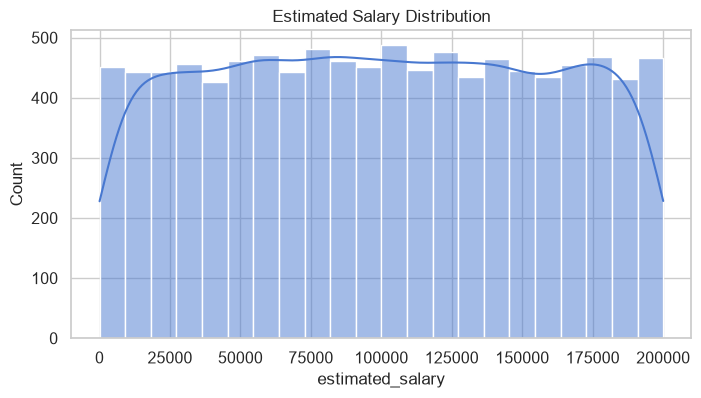

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
graph = sns.histplot(x='estimated_salary', data=df_plot, ax=ax,kde=True)  
plt.title('Estimated Salary Distribution')
plt.xlabel('estimated_salary', fontsize=12)
plt.ylabel('Count', fontsize=12)

print(df['estimated_salary'].describe().to_markdown())

Every single salary range has roughly the same number of customers. There is no "typical" salary, meaning the bank does not cater specifically to low-income, middle-class, or wealthy individuals.

|       |        age |
|:------|-----------:|
| count | 10000      |
| mean  |    38.9218 |
| std   |    10.4878 |
| min   |    18      |
| 25%   |    32      |
| 50%   |    37      |
| 75%   |    44      |
| max   |    92      |


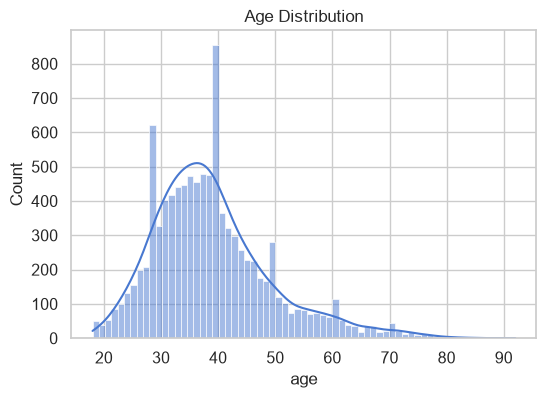

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
graph = sns.histplot(x='age', data=df_plot, ax=ax,kde=True)  
plt.title('Age Distribution')
plt.xlabel('age', fontsize=12)
plt.ylabel('Count', fontsize=12)

print(df['age'].describe().to_markdown())

Customer ages range from 18 to 92 years, indicating a relatively broad age range. The distribution is to the right. the bank has more younger and middle-age customers, while relatively fewer customers older than 50. There are noticeable peaks around ages 29, 40, and 50, suggesting that certain ages are represented more frequently in the dataset. The long right tail indicates that older customers are less common in the dataset.

|       |   balance |
|:------|----------:|
| count |   10000   |
| mean  |   76485.9 |
| std   |   62397.4 |
| min   |       0   |
| 25%   |       0   |
| 50%   |   97198.5 |
| 75%   |  127644   |
| max   |  250898   |


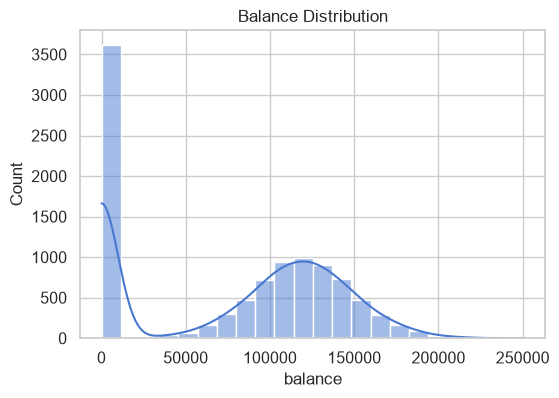

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
graph = sns.histplot(x='balance', data=df_plot, ax=ax,kde=True) 
plt.title('Balance Distribution')
plt.xlabel('balance', fontsize=12)
plt.ylabel('Count', fontsize=12)

print(df['balance'].describe().to_markdown())

The balance distribution is strongly right-skewed/bimodal. A large percentage if the customers has a balance of 0. A majority of the non-zero balances appear to be concentrated around 100000-150000. This distribution also contains a long right tail which suggests the presemce of distinct customer groups based on account balance.

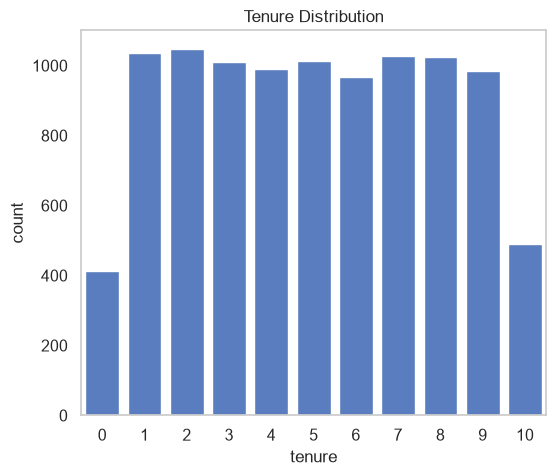

In [20]:
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='tenure', data=df_plot)
plt.grid(False)
plt.title('Tenure Distribution')
plt.show()

Customers with 1–9 years of tenure are fairly evenly distributed. Tenure 0 and 10 years have substantially fewer customers. Overall, there doesn't appear to be a strong concentration around a particular tenure period.

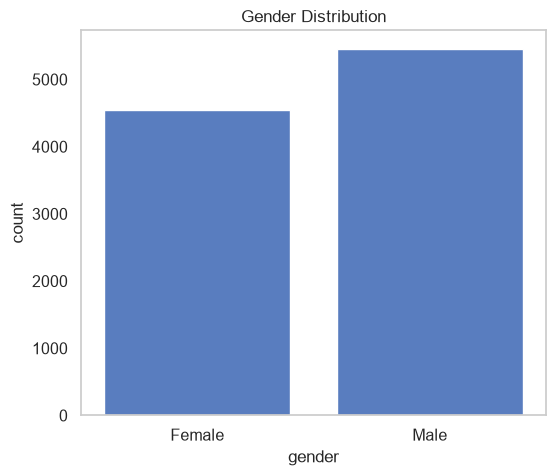

In [21]:
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='gender', data=df_plot)
plt.grid(False)
plt.title('Gender Distribution')
plt.show()

The bank has slightly more male customers than female ones.

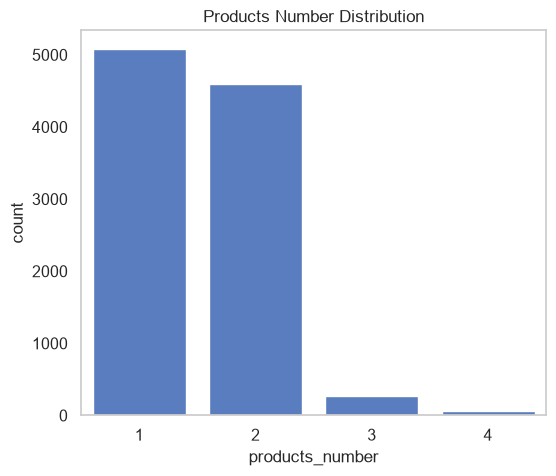

In [22]:
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='products_number', data=df_plot)
plt.grid(False)
plt.title('Products Number Distribution')
plt.show()

A majority of the customer base  owns either just one product or two products. Only a tiny handful of people have three products, and few people hve four. This means the sales team is good at getting people through the door, but completely fail at selling them extra features later on. Having half of our customers relying on just a single product is dangerous because these customers are the easiest to lose to competitors.

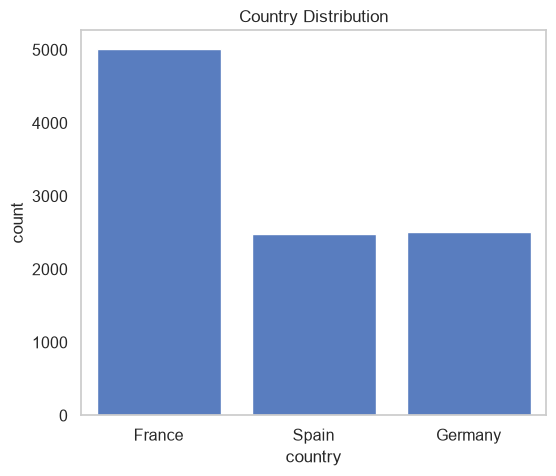

In [23]:
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='country', data=df_plot)
plt.grid(False)
plt.title('Country Distribution')
plt.show()

France is the largest market by far. It accounts for exactly half of the total database with 5,000 customers. Spain and Germany are identical in size. Each country contains roughly 2,500 customers.

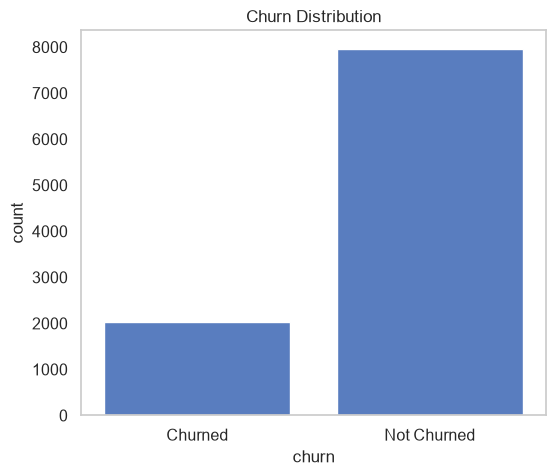

In [24]:
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='churn', data=df_plot)
plt.grid(False)
plt.title('Churn Distribution')
plt.show()

The data reveals a substantial churn rate of about 20%,. While keeping roughly 80% of our database sounds positive on the surface, losing one-fifth of the entire customer base is a heavy loss. 

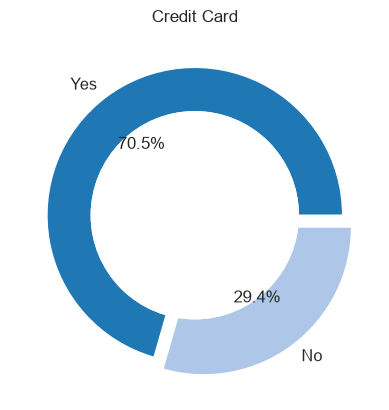

In [25]:
df_plot['credit_card'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    explode=(0, 0.10),
    colors=['#1F77B4', '#AEC7E8']
)
center = plt.Circle((0,0),.70, fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(center)
fig.gca().add_artist(center)
plt.title('Credit Card')
plt.show()

The vast majority of the customers are already using this service, with exactly 70.5% of customers owning a credit card . On the flip side, 29.4% of our customers do not have one. This means credit cards have excellent market penetration.

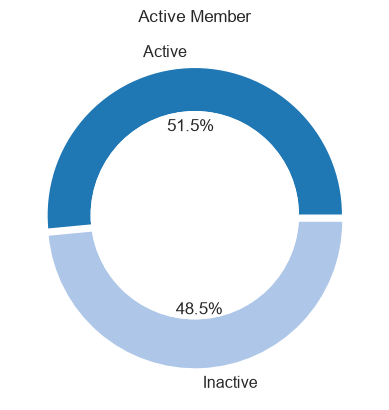

In [26]:
df_plot['active_member'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    explode=(0, 0.04),
    colors=['#1F77B4', '#AEC7E8']
)
center = plt.Circle((0,0),.70, fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(center)
fig.gca().add_artist(center)
plt.title('Active Member')
plt.show()

While 51.5% of the 10,000 customers are flagged as active, a staggering 48.5% are completely non-active. Having nearly half of the database sitting idle is highly alarming and cacn create a silent churn problem that heavily connects to the high volume of zero-balance accounts.

## 8.2 Bivariate Analysis

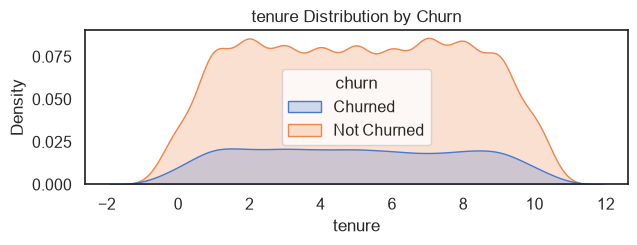

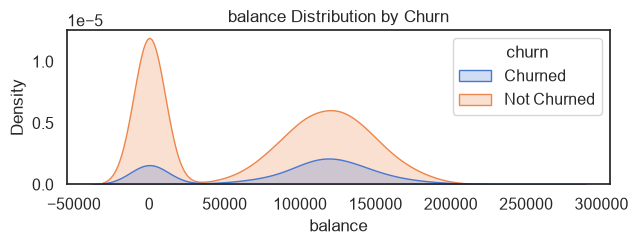

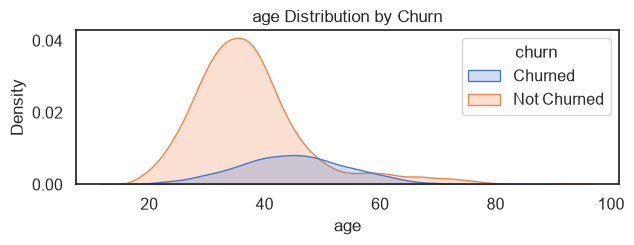

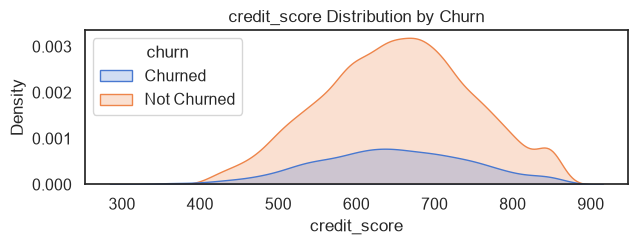

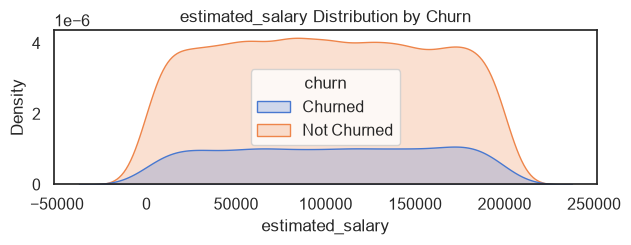

In [96]:
numerical = [ 'tenure', 'balance','age','credit_score', 'estimated_salary']
for col in numerical:
    plt.figure(figsize=(7,2))
    sns.set_style("white")
    sns.kdeplot(data=df_plot, x=col, hue='churn', fill=True)
    plt.title(f'{col} Distribution by Churn')
    plt.show

**Tenure** the distributions for churned and non-churned customers show substantial overlap, indicating that tenure alone may not be a strong predictor of churn. Although churned customers appear somewhat concentrated at the lower tenure levels, customers across a broad range of tenure periods experience churn. Therefore, tenure should be considered alongside other customer charateristics when identifying churn.
**Balance** appears to have some relationship with churn. Customers with moderate-to-high account balances appear more concentrated among the churned group, while customers with zero or very low balances are more concentrated among the non-churned group. 
**Age** appears to be an important factor associated with customer churn. Older customers appear more likely to churn than younger customers in this dataset. 
**Credit score and estimated salary** do not show a strong visual difference between churned and non-churned customers. Therefore, they do not appear to be strong discriminators of churn. 

In [ ]:
gender_counts = df_plot.groupby('gender')['churn'].value_counts(normalize=True).unstack().fillna(0)

fig, axes = plt.subplots(1, len(gender_counts.index), figsize=(10, 5))

for i, gender in enumerate(gender_counts.index):
    ax = axes[i]
    ax.pie(gender_counts.loc[gender], labels=gender_counts.columns, 
           autopct='%1.1f%%',explode=(0, 0.04), startangle=90, 
           colors=['#1F77B4', '#AEC7E8'])
    center = plt.Circle((0,0), 0.70, fc='white')
    ax.add_artist(center)
    
    # Set the title for each subplot
    ax.set_title(f'Churn Ratio for {gender}')

plt.tight_layout()
plt.show()

The churn rate for women (25.1%) is roughly 1.5 times higher than the churn rate for men (16.5%). One out of every four female customers is leaving. The bank is much better at retaining male customers, keeping 83.5% of them active compared to 74.9% of female customers.

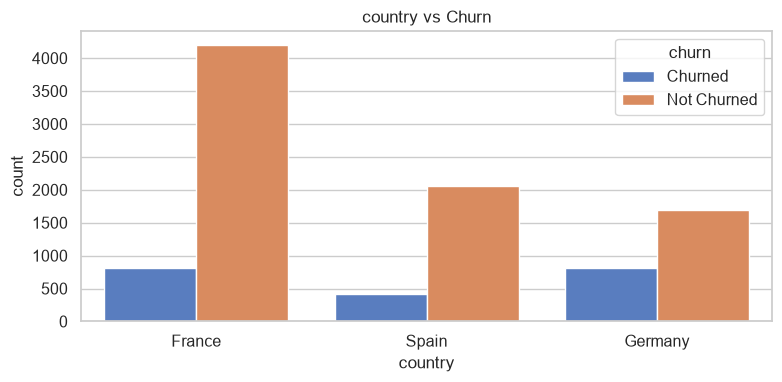

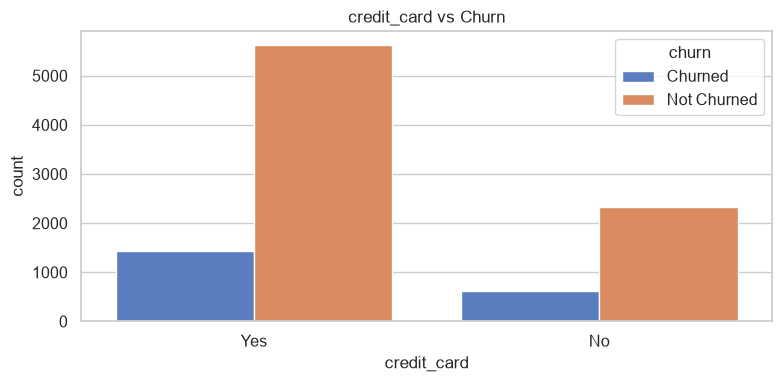

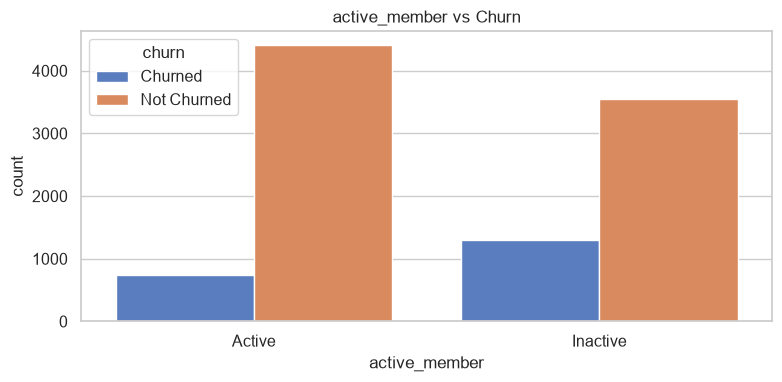

In [35]:
cat_cols = ['country', 'credit_card', 'active_member']
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_plot, x=col, hue='churn')
    plt.title(f'{col} vs Churn')
    plt.tight_layout()
    plt.show

The churn rate for France and Spain is similar at 16%, while Germany has the highest churn rate at 32%. Having a credit card does not appear to be a strong indicator of customer churn as the churn rate for both is 20%. The customers who are active members are less likely to churn with a churn rate of 14% compared to the inactive customers who churned at a rate of 27%.

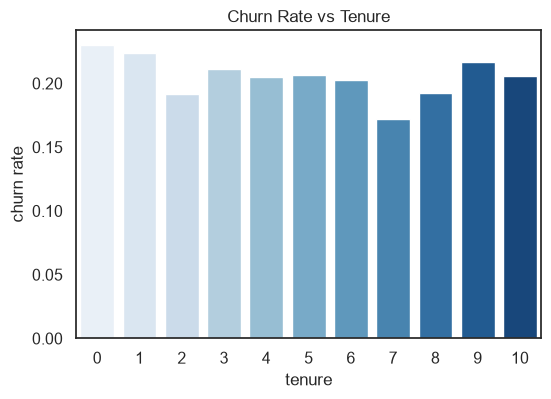

In [97]:
churn_rate = df.groupby('tenure')['churn'].mean().reset_index()
# plot churn rate
plt.figure(figsize=(6,4))
sns.barplot(data=churn_rate, x='tenure', y='churn', palette='Blues')
plt.xlabel('tenure')
plt.ylabel('churn rate')
plt.title('Churn Rate vs Tenure')
plt.show()

New customers have the highest churn rate at 23%, while the ones who have been with the bank for 7 years have the lowest churn rate at 16%.

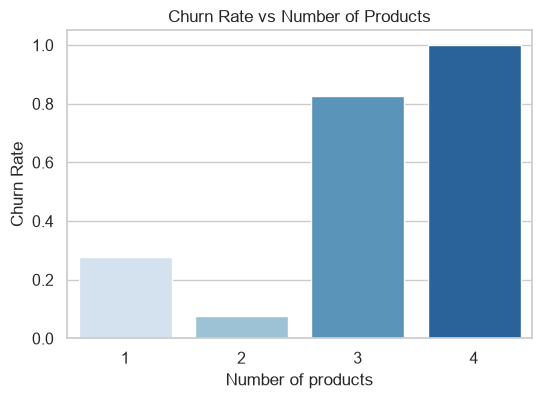

In [42]:
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()
# plot churn rate
plt.figure(figsize=(6,4))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='Blues')
plt.xlabel('Number of products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

Having more products is associated with higher churn.

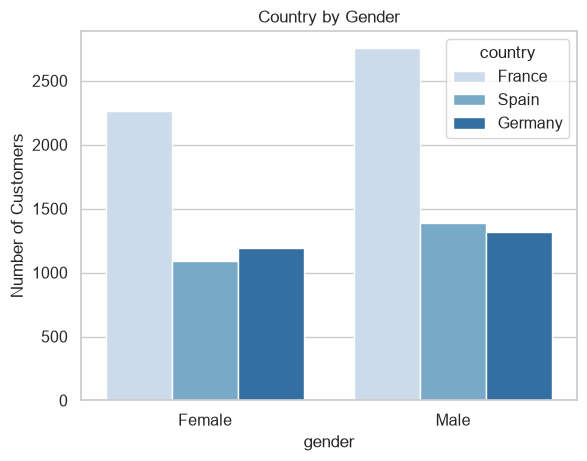

country,France,Germany,Spain
gender,,,
Female,49.768875,26.260180,23.970944
Male,50.448965,24.115815,25.435221


In [802]:
sns.countplot(data=df_plot, x='gender', hue='country',palette='Blues')

plt.title('Country by Gender')
plt.xlabel('gender')
plt.ylabel('Number of Customers')
plt.show()

pd.crosstab(df_plot['gender'],df_plot['country'],normalize='index')*100

The bank sems to have more male customers. France has the most customers, so there could be a huge potential in the market for the bank to increase recruit new customers in Spain and Germany.

## 8.3 Multivariate Analysis

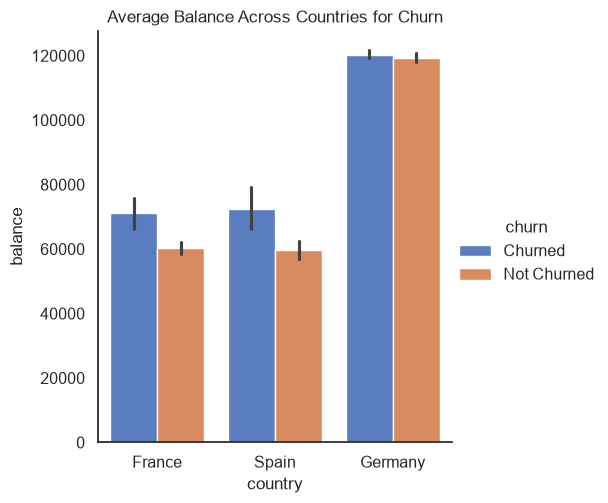

In [70]:
graph = sns.catplot(x='country', y='balance', hue='churn', data=df_plot,kind='bar')
plt.title('Average Balance Across Countries for Churn')
plt.ylabel('balance', fontsize=12)
plt.show()

Customers in Germany maintain significantly larger account balances, averaging around 120,000, compared to customers in France and Spain, averaging around 60,000 to 72,000. In Germany, the average balance is nearly identical whether a customer churned or stayed. In both France and Spain, customers who left had noticeably higher average balances than those who stayed.

**Takeaway:** 
The business is primarily losing its higher-value customers in France and Spain. In Germany, balance size does not seem to influence whether a customer leaves or stays, but because German balances are so high overall, any churn there represents a massive financial loss.

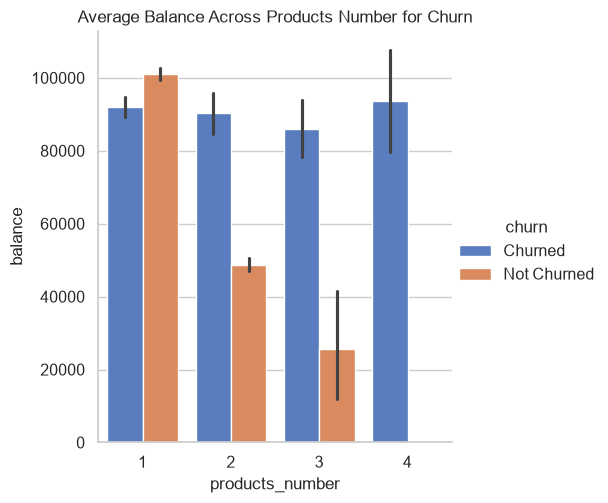

In [803]:
graph = sns.catplot(x='products_number', y='balance', hue='churn', data=df_plot,kind='bar')
plt.title('Average Balance Across Products Number for Churn')
plt.ylabel('balance', fontsize=12)
plt.show()

Across all product categories. 1 through 4, customers who leave always have a consistently high average balance. This indicates that high-wealth individuals are highly susceptible to leaving the company, no matter how many products they have adopted. As the number of products increases from 1 to 3, the average balance of loyal customers drops dramatically.

**Takeaway:** Multi-product adoption seems to correlate with customer loyalty only for lower-balance accounts. For high-balance accounts, cross-selling more products is completely failing to prevent churn.


## 8.4 Correlation Analysis

In [72]:
df_enc = df.copy()
df_enc = df_enc.drop(['customer_id'], axis = 1)
df_enc = pd.get_dummies(df_enc,drop_first = True)

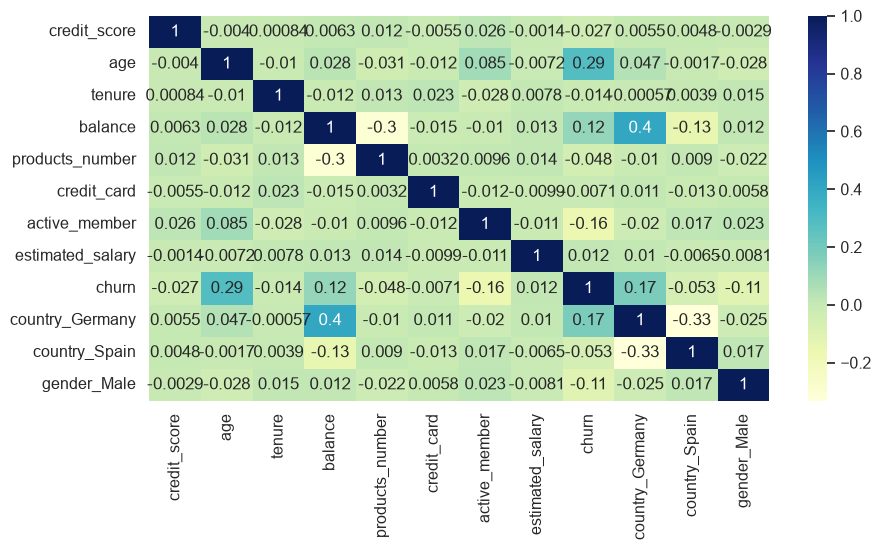

In [804]:
# Using Pearson Correlation
plt.figure(figsize=(10,5))
cor = df_enc.corr()
sns.heatmap(cor, cmap="YlGnBu", annot=True)
plt.show()

Age is the strongest positive churn predictor. As age increases, the likelihood of churn increases significantly. Customers with higher balances are counterintuitively showing a higher tendency to churn. The active_member variable has a negative correlation with churn. It confirms that active members are significantly less likely to churn than inactive ones.

There is a moderate-to-strong positive correlation between being from Germany and having a high account balance, as seen from previous plots.

Estimated_salary, credit_score, credit_card & tenure show nearly zero relationship to churn or any other demographic behavior.

## 8.5 Outliers

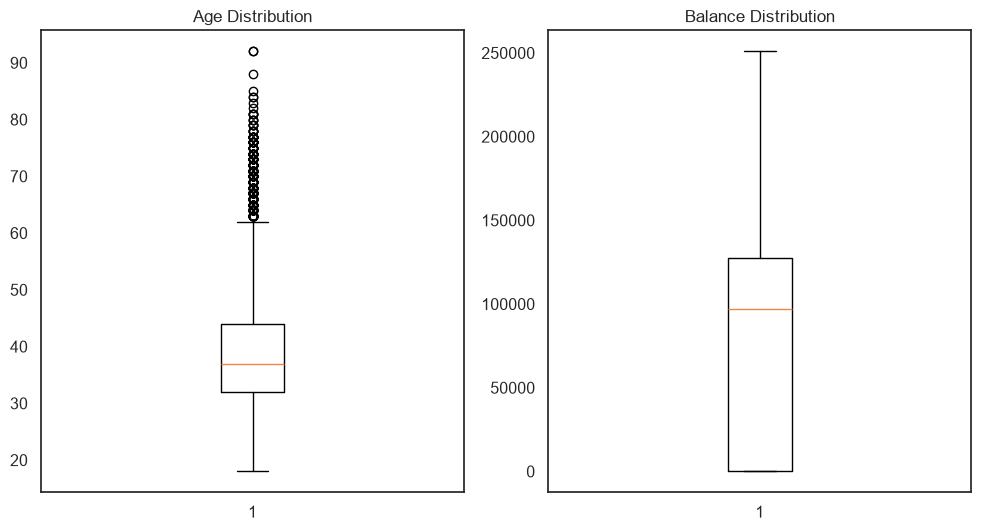

In [78]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=False)

# Plot on the first axis
ax1.boxplot(df['age'])
ax1.set_title('Age Distribution')

# Plot on the second axis
ax2.boxplot(df['balance'])
ax2.set_title('Balance Distribution')

plt.show()

##### Age
The typical customer is between 32 and 44 years old. The outliers represent senior citizens around age 62 to 92. Older customers often show completely different loyalty and churn patterns than younger demographics, so these outliers will not be dropped. 

##### Balance
There is a massive cluster of customers with a exactly a $0.00 balance. This heavily skews the distribution downwards, making your median look artificially low. But these are not outliers, they are a distinct structural segment of the user base. Traditional transformations like np.log() will fail here because (log(0) is undefined. Instead, I will create a binary indicator feature to help the machine learning model differentiate these users instantly.

## 8.6 Summary of EDA

The exploratory analysis revealed that the bank has a hard time retaining female customers and customers from Germany. In addition, credit card, credit score, and estimated salary do not have strong indicators for customer churn, therefore they will not be included in the modeling stage. Customer churn seems to be influenced by a lot of factors according to the exploratory analysisage and the number of products a customer has

<a id="pp"></a>
# 9. Feature Engineering

Feature engineering is the process of selecting and transforming variables into an ideal format before using them in predictive model. The features in the data will directly influence the predictive models used and the results obtained

## 9.1  Adding Features
Add new meaningful features based on the above exploration. Features that can capture hidden relationships in the and help the model make smarter predictions.

In [866]:
df_add = df.copy()

# Age group
df_add['age_group'] = pd.cut(df_add['age'], bins=[0,25,35,45,55,65,100], 
                            labels=['less_than_25', '25-34', '35-44', '45-54', '55-64', '65+'])
# Tenure
df_add['tenure_bucket'] = pd.cut(df_add['tenure'], bins=[0,3,6,9,100], 
                            labels=['less_than_3', '4-6', '7-8', '9+'])

# Credit score
df_add['credit_score_group'] = pd.cut(df_add['credit_score'], bins=[0,500,700,900],
                               labels=['less_than_500','500-699', '700-900'])

# Flag zero-balance accounts
df_add['is_balance_zero'] = (df_add['balance'] == 0).astype(int)

# Flag moderate balance
df_add['moderate_balance'] = ((df_add['balance'] > 0) & (df_add['balance']< df_add['balance'].quantile(0.75))).astype(int)

# Flag high balance
df_add['high_balance'] = (df_add['balance'] > df_add['balance'].quantile(0.75)).astype(int)

# Average balance per age group
df_add['balance_per_age_group'] = (df_add.groupby('age_group')['balance'].transform('mean'))

These features are created on the entire dataset before the train/test split, because they are calculated only from information that belongs to each individual customer. They do not use the target (churn) or learn anything from the dataset as a whole.

In [844]:
age_ct = pd.crosstab(df_add['age_group'], df_add['churn'], 
                     normalize='index') * 100

tenure_ct = pd.crosstab( df_add['tenure_bucket'], df_add['churn'],
                    normalize='index') * 100

credit_ct = pd.crosstab( df_add['credit_score_group'], df_add['churn'],
                    normalize='index') * 100

result = pd.concat([age_ct, tenure_ct, credit_ct],axis=1,
                    keys=['Age', 'Tenure', 'Credit Score'])
result

Age                Tenure            Credit Score  \
churn                  0          1          0          1            0   
less_than_25   92.471358   7.528642        NaN        NaN          NaN   
25-34          91.501976   8.498024        NaN        NaN          NaN   
35-44          80.380086  19.619914        NaN        NaN          NaN   
45-54          49.427918  50.572082        NaN        NaN          NaN   
55-64          51.679104  48.320896        NaN        NaN          NaN   
65+            86.742424  13.257576        NaN        NaN          NaN   
less_than_3          NaN        NaN  79.107374  20.892626          NaN   
4-6                  NaN        NaN  79.514825  20.485175          NaN   
7-8                  NaN        NaN  80.671716  19.328284          NaN   
9+                   NaN        NaN  79.387755  20.612245          NaN   
less_than_500        NaN        NaN        NaN        NaN    76.360809   
500-699              NaN        NaN        NaN        NaN    79.714789   
700-900              NaN        NaN        NaN        NaN    80.134788   

                          
churn                  1  
less_than_25         NaN  
25-34                NaN  
35-44                NaN  
45-54                NaN  
55-64                NaN  
65+                  NaN  
less_than_3          NaN  
4-6                  NaN  
7-8                  NaN  
9+                   NaN  
less_than_500  23.639191  
500-699        20.285211  
700-900        19.865212

After grouping some features so that they have meaningful business and statistical interpretation, age will be used in the model because the churn rate is significantly different across the age groups. Both tenure_bucket and credit_score_group have more or less churn rates across the formed groups, so they will be excluded when modeling. This is the second confirmation that both credit_score and tenure should be dropped, as the heat map showed that they had nearly zero relationship to churn or any other demographic behavior. Credit_Card and estimated_salary will also be excluded because of similar reasons.

In [845]:
df_add = df_add.drop(['customer_id','credit_score','credit_card','age','tenure','balance',
                      'tenure_bucket','estimated_salary','credit_score_group'], axis = 1) 
df_add.head(2)

,country,gender,products_number,active_member,churn,age_group,is_balance_zero,moderate_balance,high_balance,balance_per_age_group
0,France,Female,1,1,1,35-44,1,0,0,76830.514649
1,Spain,Female,1,1,0,35-44,0,1,0,76830.514649


## 9.2. Select feature and label variables

In [846]:
# Assign feature and response variables
X = df_add.drop(columns=['churn'])
y = df_add['churn']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Essential for imbalanced churn data
)
print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

Training shape: (8000, 9), Test shape: (2000, 9)


## 9.3  Encoding and Scaling

In [847]:
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender']) 

In [848]:
from sklearn.compose import ColumnTransformer

num_cols = ['products_number','balance_per_age_group']
cat_cols = ['country','age_group']
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols),],
        remainder="passthrough", verbose_feature_names_out=False).set_output(transform='pandas')

# Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [849]:
X_train_processed.head()

,products_number,balance_per_age_group,country_Germany,country_Spain,age_group_35-44,age_group_45-54,age_group_55-64,age_group_65+,age_group_less_than_25,gender,active_member,is_balance_zero,moderate_balance,high_balance
2151,-0.910256,1.769607,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,1,0,0
8392,-0.910256,-0.855981,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,1,0
5006,0.808830,0.129711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,1,0
4117,0.808830,0.129711,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0,1,0,0
7182,0.808830,1.863053,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0,1,0


#### Correlation Check

I used a heatmap to rule out any features that are highly correlated

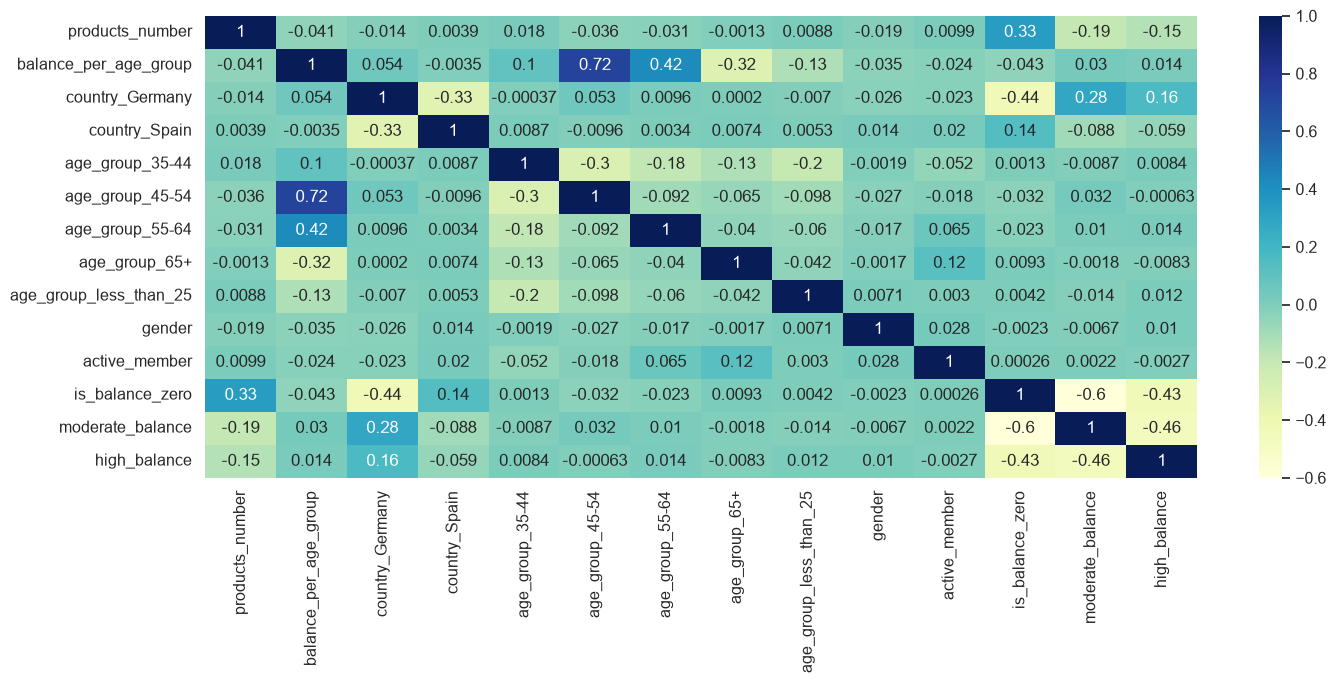

In [850]:
# Using Pearson Correlation
plt.figure(figsize=(16,6))
cor = X_train_processed.corr()
sns.heatmap(cor, cmap="YlGnBu", annot=True)
plt.show()

There is no correlation higher than 0.85 (-0.85), so the features will be included in the modeling stage.

## 9.3  Feature Importance

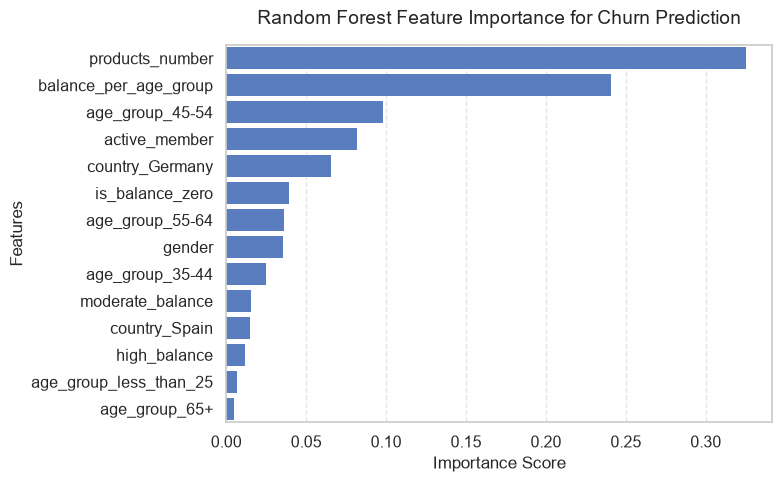

In [851]:
# Initialize the model with class weights balanced to counter churn minority
model = RandomForestClassifier(n_estimators=100, random_state=42, 
                               class_weight='balanced', # Crucial for handling imbalanced datasets
                               max_depth=8)              # Keeps the model from overfitting early
model.fit(X_train_processed, y_train)

# Extract importance scores
importances = model.feature_importances_
feature_names = X_train_processed.columns

# Structure into a clean DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names,
                               'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the Feature Importances
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, 
            edgecolor='none')

plt.title('Random Forest Feature Importance for Churn Prediction', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Random Forest feature importance identified products_number as the most influential predictor, followed by balance_per_age_group, active_member, age-group indicators and country. The engineered feature, is_balance_zero, also demonstrates predictive importance.

The results also suggest:
| age_group | Importance |  |
|---------|---------|----------|
| **45–54** | very important|
| **55–64** | important |
| **35–44** | moderately important |
| **<25** | relatively low|
| **65+** | very low |

These are not necessarily  independent business features. The model is essentially learning that certain age groups are associated with different levels of churn which is a useful business insight.
    

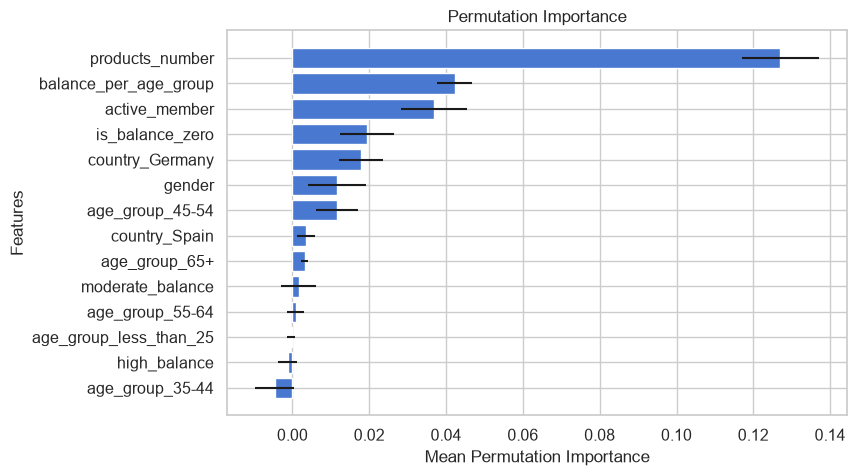

In [854]:
# To evaluate model performance on test by shuffling feature columns.
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(model,X_test_processed,
                                         y_test, n_repeats=10, random_state=42,
                                         scoring='f1')
perm_df = pd.DataFrame({'Feature': X_test_processed.columns,
                        'Importance': perm_importance.importances_mean,
                        'Std': perm_importance.importances_std     #to see whether an importance is consistently positive or whether it varies substantially across the 10 permutations.
                       }).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(8, 5))

plt.barh(
    perm_df['Feature'],
    perm_df['Importance'],
    xerr=perm_df['Std']
)

plt.xlabel('Mean Permutation Importance')
plt.ylabel('Features')
plt.title('Permutation Importance')
plt.gca().invert_yaxis()

plt.show()

Permutation importance identified products_number, balance_per_age_group, active_member, is_balance_zero, and country_Germany as the most influential features for the Random Forest model's F1 performance. Several features, including moderate_balance, high_balance, age_group_less_than_25, and age_group_leaa_than_25, showed near-zero or slightly negative permutation importance, suggesting limited contribution to predictive performance under the Random Forest model.    

<a id="mm"></a>
# 10. Modeling

In this section, machine learning algorithms that will predict the labels from the features presented will be trained. Several models (logistic rgeression, Naive Bayes, Random Forest, linear support vector machine, neural network, decision tree and XGBoost) will be trained in order to test their performance and see which one does the best job classifying our unseen data. Below is a basic breakdown of each model.

1. **Logistic Regression** - Logistic regression is one of the most widely used algorithms for classifying catgorical data. This method predicts the probability of an observation belonging to a class using a logit function. A probability threshold is determined and is used to allocate an observation to a label. 0.5 is typically chosen as the threshold. The logit function is defined as follows:

$$P(X) = \displaystyle \frac{e^{\beta_0 + \beta_1 X}}{1+e^{\beta_0 + \beta_1 X}}$$

where $P(X)$ is the probability of X belonging to class 1, and $\beta_0$ and $\beta_1$ are the intercept and regression coefficient respectively. $P(X)$ > 0.1 is assigned class 1 and $P(X)$ < 0 is assigned class 0. With multiclasses, a "One vs Rest" approach can be used where a logistic regression model is trained for each label or cross-entropy loss.

2. **Naive Bayes** - This method uses the principle of Bayes Theorem (conditional probability) to classify observations into classes. The algorithm assumes that there is independence between variables (X and Y). This is displayed in the equation

$$
P(X \cap Y) = P(X)P(Y)
$$

Even besides this assumption, it works well with multiclass classification. The algorithm calculates the probability of each labels for a given text and then outputs the label with the highest one.

3. **Linear Support Vector Machine** - Support vector machines are based on the idea of hyperplanes seperating classes in a  linear manner. Support vectors are data points found close to the hyperplane and are considered critical points in the dataset as they impact the position of the hyperplane. The further away that points are from hyperplanes, the better.

4. **Neural Network** - A neural network is essentially a network of functions feeding into each other and are designed to recognise patterns.

5. **Decision Tree** - A decision tree algorithms make decisions by selecting an attribute and makes it a decision node. At the decision node, smaller subsets off the data is created by splitting the data according to the outcome of a condition set. This process is repeatedly recursively until the maximum depth of the trees is reached. In classifitcaton, the split points can be made using the Information Gain, Gain Ratio and Gini Index methods.

6. **XGBoost** - XGBoost (eXtreme Gradient Boosting) is a type of ensemble model (a method that trains and predicts many models at once to produce a single superior output). It is based on the concept of boosting weak learners to strong learners.

In [837]:
# Define multiple models to test which one gives us the best accuracy
model_dict = {'Random Forest': RandomForestClassifier(n_estimators=500,class_weight='balanced',
                                                      random_state=42,max_depth=8),
              'Logistic Regression': LogisticRegression(C=0.1,penalty='l2',class_weight='balanced',
                                                        solver='liblinear',max_iter=1000,random_state=42),
              'LinearSVM': SGDClassifier(loss='log_loss',penalty='l2',alpha=0.001,class_weight='balanced',
                                            max_iter=2000,learning_rate='optimal',random_state=42),
              'Non-linear SVM': SVC(kernel='rbf',C=1,gamma='scale',class_weight='balanced',
                                    random_state=42,probability=True),
              'Neural Network': MLPClassifier(hidden_layer_sizes=(50, 25),activation='relu',solver='adam',
                                             alpha=0.01,learning_rate_init=0.001,batch_size=64,
                                             max_iter=1000,early_stopping=True,random_state=42),
              'Decision Tree': DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,
                                            min_samples_leaf=5,class_weight='balanced',random_state=42),
              'XGBoost': XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=3,min_child_weight=3,
                                        subsample=0.8,colsample_bytree=0.8,gamma=0,reg_alpha=0.1,
                                        reg_lambda=10,random_state=42,eval_metric='logloss')
              }

A classification report is a representation of the main classification metrics on a per-class basis. Its used to describe the performance of a classifier. This gives a deeper intuition of the classifier behavior over global accuracy.

The metrics are defined in terms of true and false positives, and true and false negatives. Positive and negative in this case are generic names for the classes of a binary classification problem. A true positive is when the actual class is positive as is the estimated class. A false positive is when the actual class is negative but the estimated class is positive. This is also referred to as a Type 1 error. A true negative is when the actual class is negative as is the estimated class. A false negative is when the actual class is negative but the estimated class is positive. This is also referred to as a Type 2 error. Using this terminology the metrics are defined as follows:

* Precision - This is the ability of a classiifer not to label an instance positive that is actually negative.


$$ Precision = \frac{TP}{TP \space + FP} = \frac{TP}{Total \space Predicted \space Positive} $$

* Recall - This is the ability of a classifier to find all positive instances. 

$$ Recall = \frac{TP}{TP \space + FN} = \frac{TP}{Total \space Actual \space Positive}$$


* F1 score - The F1 score is a weighted harmonic mean of precision and recall such that the best score is 1.0 and the worst is 0.0. 


$$F_1 = 2 \times \frac {Precision \space \times \space Recall }{Precision \space + \space Recall }$$

In [838]:
classifier_results_dict = defaultdict(list)
for mod_name, model in model_dict.items():
    print(mod_name)  # keep track of progress
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    precision_v = precision_score(y_test, y_pred)
    recall_v = recall_score(y_test, y_pred)
    f1_v = f1_score(y_test, y_pred)

    classifier_results_dict['Model'].append(mod_name)
    classifier_results_dict[('Precision')].append(precision_v)
    classifier_results_dict[('Recall')].append(recall_v)
    classifier_results_dict[('F1-score')].append(f1_v)

classifier_results_df = pd.DataFrame(classifier_results_dict).sort_values(by='Recall',
                                  ascending=False).reset_index(drop=True)

Random Forest
Logistic Regression
LinearSVM
Non-linear SVM
Neural Network
Decision Tree
XGBoost


In [839]:
classifier_results_df

,Model,Precision,Recall,F1-score
0,Decision Tree,0.393462,0.798526,0.527170
1,Non-linear SVM,0.477237,0.746929,0.582375
2,LinearSVM,0.389628,0.719902,0.505608
3,Random Forest,0.501742,0.707617,0.587156
4,Logistic Regression,0.410370,0.680590,0.512015
5,Neural Network,0.740741,0.491400,0.590842
6,XGBoost,0.764463,0.454545,0.570108


In [768]:
#log metrics on Comet,where 'metrics' is a dictionary of metrics
metric_columns = ['Precision','Recall','F1-score']

# Log each model's metrics separately
for _, row in classifier_results_df.iterrows():
    model_name = row['Model']
    metrics = row[metric_columns].to_dict()
    experiment.log_metrics(metrics,prefix=model_name)

<a id="me"></a>
# 11. Model Evaluation

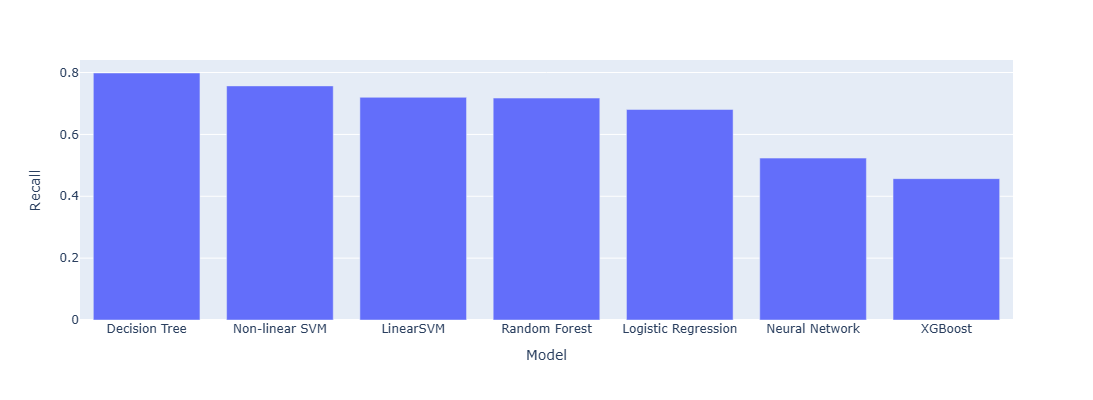

In [769]:
fig = px.bar(classifier_results_df, x="Model", y="Recall", 
             barmode='group', height=400)
fig.show()

In [881]:
# Best Model: Decision Tree
model_dt = DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,
                                            min_samples_leaf=5,class_weight='balanced',random_state=42)

In [882]:
model_dt.fit(X_train_processed, y_train)
y_pred = model_dt.predict(X_test_processed)

precision_v = precision_score(y_test, y_pred)
recall_v = recall_score(y_test, y_pred)
f1_v = f1_score(y_test, y_pred)
print("Recall:",recall_v)
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Recall: 0.7985257985257985
ROC-AUC: 0.7420124284531066


In [883]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1593
           1       0.39      0.80      0.53       407

    accuracy                           0.71      2000
   macro avg       0.66      0.74      0.66      2000
weighted avg       0.82      0.71      0.74      2000



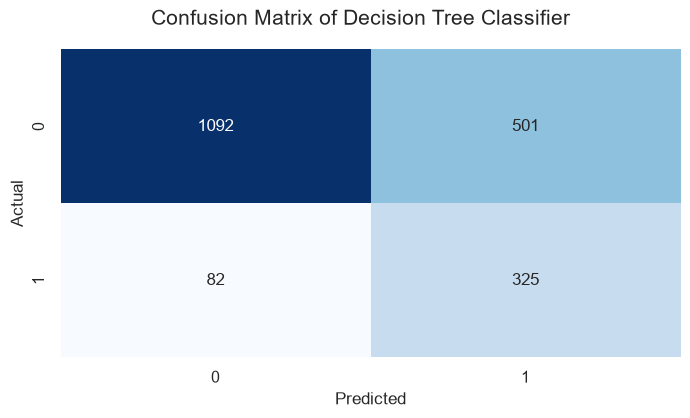

In [884]:
# Enhance confusion matrix using a heatmap
cm =confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cm, ax = ax, annot=True, fmt='g', cbar=False, 
            cmap='Blues')
plt.suptitle('Confusion Matrix of Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

The Decision Tree achieved a churn recall of approximately 80%, successfully identifying the majority of customers at risk of churn. However, its precision of 39.3% indicates that the model also classified a substantial number of non-churning customers as potential churners. This suggests that while the model is effective for identifying customers who may require retention attention, further optimization could reduce false positives.

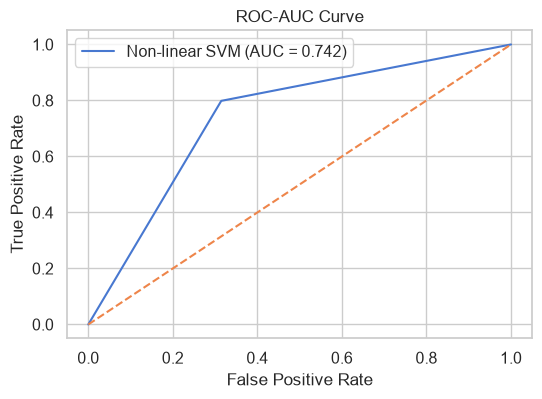

In [885]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Non-linear SVM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()

The Decision Tree demonstrated acceptable discriminatory power, achieving an AUC of 0.742. This indicates that the model has a 74.2% probability of ranking a randomly selected churned customer higher than a randomly selected non-churned customer. The ROC curve shows a notable operating point at approximately a False Positive Rate (FPR) of 0.31 and a True Positive Rate (TPR) of 0.80, representing a balance between identifying churners and limiting false positives. Overall, the results suggest that the model has a reasonable ability to distinguish between customers who are likely to churn and those who are likely to remain, while also highlighting the trade-off between churn detection and false-positive predictions.

#### Hyperparameter Tuning

In [696]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'class_weight': [None, 'balanced']}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [886]:
# Best parameters
print("Best parameters:")
print(grid_dt.best_params_)

Best parameters:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [889]:
# Best Model
best_dt = grid_dt.best_estimator_
y_pred = best_dt.predict(X_test_processed)

precision_v = precision_score(y_test, y_pred)
recall_v = recall_score(y_test, y_pred)
f1_v = f1_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.68      0.79      1593
           1       0.39      0.81      0.53       407

    accuracy                           0.70      2000
   macro avg       0.66      0.74      0.66      2000
weighted avg       0.82      0.70      0.73      2000

ROC-AUC: 0.744074583057634


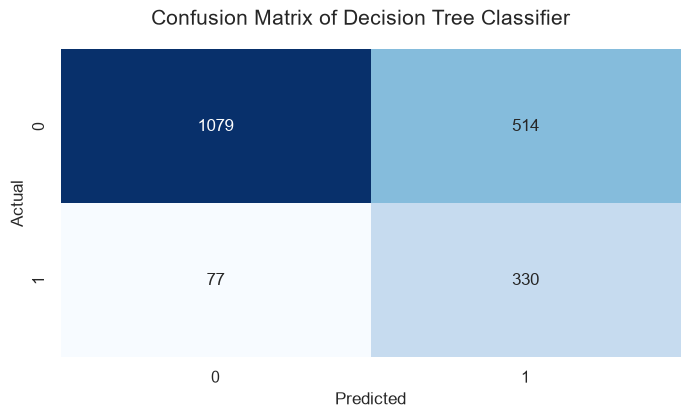

In [888]:
# Enhance confusion matrix using a heatmap
cm =confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cm, ax = ax, annot=True, fmt='g', cbar=False,
            cmap='Blues')
plt.suptitle('Confusion Matrix of Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The final model achieved 81% recall for churners, successfully identifying the majority of customers at risk of leaving. However, the 39% precision indicates a relatively high false-positive rate, highlighting a trade-off between identifying potential churners and avoiding unnecessary retention interventions.

### File for model deployment

In [864]:
import joblib

model_bundle = {
    "model": best_dt,
    "preprocessor": preprocessor,
    "label_encoder": le
}

joblib.dump(model_bundle, "churn_model.pkl")

['churn_model.pkl']

<a id="bi"></a>
# 12. Business Recommendation

The analysis provides several opportunities for the business to improve customer retention:

**Prioritise early identification of at-risk customers:** With approximately 80% recall, the model can be used to create a list of customers who are more likely to churn, allowing the business to intervene before they leave.

**Develop targeted retention campaigns:** Rather than offering the same incentive to every customer, churn predictions can be combined with customer characteristics and behavioural patterns to develop more personalised retention strategies.

**Focus resources on high-risk customers:** The business can assign higher-priority retention actions to customers with the highest predicted probability of churn. This can help reduce unnecessary spending on customers who are unlikely to leave.

**Use customer segmentation alongside churn prediction:** Customer segments can help the business understand that different groups may require different retention strategies. For example, customers with different purchasing behaviours, account characteristics or engagement levels may respond differently to retention offers.

**Balance retention costs against false positives:** The model currently identifies a considerable number of non-churning customers as potential churners. However, this may still be commercially acceptable if the cost of a retention campaign is relatively low compared with the revenue lost when a genuine churner is missed.

The key business value of this project is moving from reactive to proactive customer retention. Instead of waiting until customers leave, the business can use predictive analytics to identify customers who may be at risk and intervene earlier. Although the current model can still be improved—particularly in reducing false positives—it demonstrates how customer data and machine learning can support more targeted retention decisions, better allocation of marketing resources, and potentially lower customer churn and revenue loss.

<a id="con"></a>
# 13. Conclusion

The customer churn analysis demonstrated that machine learning can be used to identify customers who are at risk of leaving, providing a basis for proactive customer-retention strategies. Several classification models were evaluated, with the Decision Tree providing a useful balance between interpretability and churn detection. The final model achieved an AUC of 0.742, indicating acceptable discriminatory ability, while its recall of approximately 79.9% shows that it was able to identify the majority of customers who actually churned. However, the model produced a relatively high number of false positives, resulting in a churn precision of approximately 39.3%. Overall, the model provides a practical starting point for a data-driven churn-management strategy, particularly where the cost of missing a potential churner is greater than the cost of contacting a customer who ultimately does not churn.

<a id="ecomet"></a>
# 14. End Commet Experiment

In [890]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : 5th one
COMET INFO:     url                   : https://www.comet.com/msibivee-gmail-com/churn-prediction/05e86ffb580a49cc9d234638c12e9661
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     Decision Tree_F1-score [3]        : (0.527169505271695, 0.5708245243128964)
COMET INFO:     Decision Tree_Precision [3]       : (0.3934624697336562, 0.5009276437847866)
COMET INFO:     Decision Tree_Recall [3]          : (0.6633906633906634, 0.7985257985257985)
COMET INFO:     LinearSVM_F1-score [3]            : (0.5091225021720244, 0.5208526413345691)
COMET INFO:     LinearSVM_Precision [3]           : (0.39381720430107525, 0.4181547619047619)
COMET INFO: 